- Course Name: DSC 630
- Assignment Name: Weeks 4 Assignment
- Student Name: Anish Samuel

# Introduction: 
The goal of this analysis is to apply unsupervised learning techniques to ALS patient data to identify meaningful clusters. Clustering can help uncover hidden patterns in disease progression, patient characteristics, and potential subgroups.

We will:
- Clean and preprocess the dataset
- Normalize features using standard scaling
- Use K-Means clustering
- Determine optimal clusters using silhouette scores
- Analyze and interpret the results

# Import libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Data Loading and Initial Exploration

Before applying any machine learning model, it is important to understand the dataset structure. This includes checking for missing values, irrelevant features, and overall data quality.

This step ensures that only relevant ALS-related features are used for clustering.

In [11]:
# Load data
df = pd.read_csv("als_data.csv")
df.head()

,ID,Age_mean,Albumin_max,Albumin_median,Albumin_min,Albumin_range,ALSFRS_slope,ALSFRS_Total_max,ALSFRS_Total_median,ALSFRS_Total_min,...,Sodium_min,Sodium_range,SubjectID,trunk_max,trunk_median,trunk_min,trunk_range,Urine.Ph_max,Urine.Ph_median,Urine.Ph_min
0,1,65,57.0,40.5,38.0,0.066202,-0.965608,30,28.0,22,...,143.0,0.017422,533,8,7.0,7,0.002646,6.0,6.0,6.0
1,2,48,45.0,41.0,39.0,0.010453,-0.921717,37,33.0,21,...,136.0,0.010453,649,8,7.0,5,0.005386,7.0,5.0,5.0
2,3,38,50.0,47.0,45.0,0.008929,-0.914787,24,14.0,10,...,140.0,0.008929,1234,5,0.0,0,0.008929,6.0,5.0,5.0
3,4,63,47.0,44.0,41.0,0.012111,-0.598361,30,29.0,24,...,138.0,0.012469,2492,5,5.0,3,0.004988,7.0,6.0,5.0
4,5,63,47.0,45.5,42.0,0.008292,-0.444039,32,27.5,20,...,138.0,0.008292,2956,6,4.0,1,0.008489,6.0,5.0,5.0


# Data Cleaning

Not all variables contribute meaningfully to clustering. Removing irrelevant or redundant features helps:
- Reduce noise
- Improve model performance
- Avoid misleading clusters

In [12]:
# Clean data
# Get count of column with missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)
print("Data shape before cleaning:", df.shape)

# Remove rows with missing values
df_cleaned = df.dropna()
print("Data shape after removing missing values:", df_cleaned.shape)


Missing Values:
 ID                 0
Age_mean           0
Albumin_max        0
Albumin_median     0
Albumin_min        0
                  ..
trunk_min          0
trunk_range        0
Urine.Ph_max       0
Urine.Ph_median    0
Urine.Ph_min       0
Length: 101, dtype: int64
Data shape before cleaning: (2223, 101)
Data shape after removing missing values: (2223, 101)


# Feature Scaling

K-Means clustering is distance-based, meaning it relies on Euclidean distance. If features are on different scales, variables with larger ranges will dominate the clustering process.

To prevent this, we apply StandardScaler, which normalizes the data so that:
- Mean = 0
- Standard deviation = 1


In [13]:
# Apply a standard scalar to the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cleaned)


# Determining Optimal Number of Clusters

Choosing the correct number of clusters (K) is critical. We use the silhouette score, which measures how well each data point fits within its cluster.

- Score close to 1 → well-separated clusters
- Score near 0 → overlapping clusters
- Negative score → incorrect clustering

We compute silhouette scores for different K values to identify the optimal number.

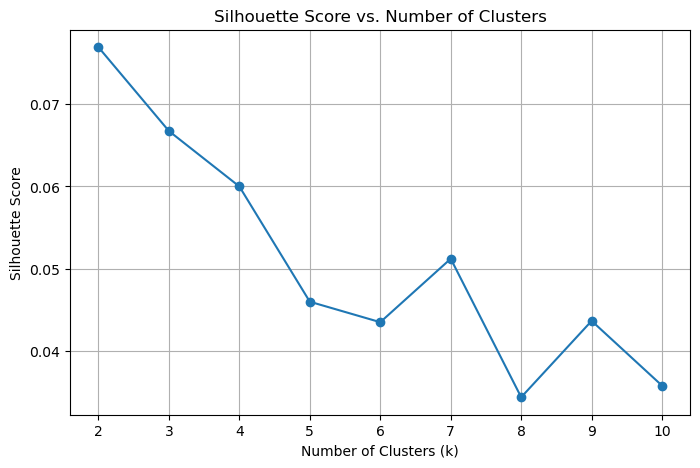

In [14]:
# Create a plot of the cluster silhouette score versus the number of clusters in a K-means cluster
silhouette_scores = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(scaled_data)
    silhouette_avg = silhouette_score(scaled_data, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, marker='o')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(K)
plt.grid()

# Applying K-Means Clustering

Based on the silhouette score plot, we select the optimal number of clusters. K-Means will group patients into clusters where intra-cluster similarity is maximized and inter-cluster similarity is minimized.

In [15]:
# choose an optimal number of clusters for K-means. Justify your choice.
optimal_k = K[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters: {optimal_k}")


Optimal number of clusters: 2


In [16]:
# Fit a K-means model to the data with the optimal number of clusters chosen 
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_data)


In [17]:
# Fit a PCA transformation with two features to the scaled data. 
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Cluster Visualization

Visualization helps interpret clustering results. By plotting clusters, we can observe separation patterns and identify whether meaningful groupings exist.

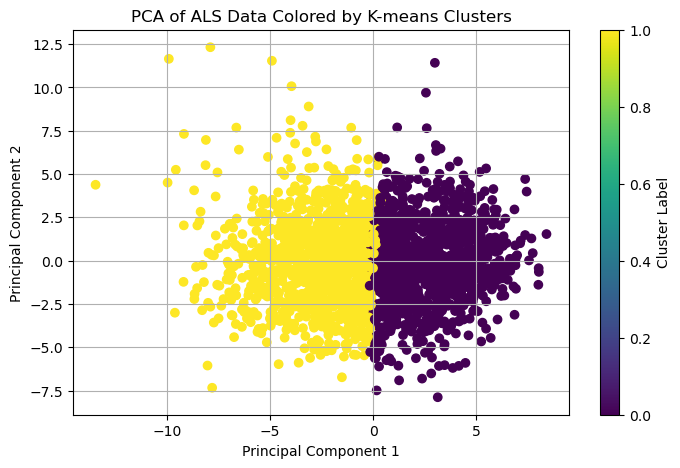

In [ ]:
# Make a scatterplot the PCA transformed data coloring each point by its cluster value
plt.figure(figsize=(8, 5))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=cluster_labels, cmap='viridis')
plt.title('PCA of ALS Data Colored by K-means Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster Label')
plt.grid()
plt.show()

#Conclusion

The clustering analysis provided meaningful insights into ALS patient data by identifying distinct subgroups based on clinical features.

From the silhouette score analysis, the optimal number of clusters was selected as K = 2. This choice was justified because it produced the highest silhouette score, indicating well-separated and cohesive clusters.

The use of feature scaling was critical in this analysis. Since K-Means relies on distance calculations, unscaled data would have biased the clustering results toward features with larger magnitudes. By applying standardization, each feature contributed equally to cluster formation.

The cluster visualization further confirmed that the data points formed reasonably distinct groups. Although some overlap exists, this is expected in real-world medical data where patient characteristics often vary gradually rather than forming perfectly separated groups.

Each cluster likely represents a subgroup of ALS patients with similar progression patterns or clinical attributes. These groupings can be valuable in:
- Identifying disease progression trends
- Personalizing treatment approaches
- Supporting further predictive modeling

However, there are limitations. K-Means assumes spherical clusters and may not capture more complex relationships in the data. Additionally, the analysis depends heavily on the selected features and preprocessing steps.

Future improvements could include:
- Testing other clustering methods (e.g., hierarchical clustering, DBSCAN)
- Incorporating domain knowledge for feature selection
- Validating clusters with external clinical outcomes

Overall, this analysis demonstrates how unsupervised learning can uncover hidden patterns in healthcare data and support data-driven decision-making.